<a href="https://colab.research.google.com/github/og-cz/CCADMACL/blob/main/Exercise3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [1]:
!pip install scikit-learn

In [2]:
import kagglehub
import os
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import sklearn

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

In [3]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [4]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [5]:
# put your answer here
df.head(5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [6]:
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [7]:
# put your answer here
df['Name'].nunique()

800

In [8]:
print(df['Legendary'].value_counts())


Legendary
False    735
True      65
Name: count, dtype: int64



List all columns available (3 pts)

In [9]:
# put your answer here
print(df.columns.tolist())

['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']


## 2: Select Features & Clean the Data (8 pts)
`
Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [10]:
# put your answer here
df_selected = df.drop(columns=['Name', 'Type 1', 'Type 2', 'Legendary'])
df_selected

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,318,45,49,49,65,65,45,1
1,2,405,60,62,63,80,80,60,1
2,3,525,80,82,83,100,100,80,1
3,3,625,80,100,123,122,120,80,1
4,4,309,39,52,43,60,50,65,1
...,...,...,...,...,...,...,...,...,...
795,719,600,50,100,150,100,150,50,6
796,719,700,50,160,110,160,110,110,6
797,720,600,80,110,60,150,130,70,6
798,720,680,80,160,60,170,130,80,6


Are there any missing values? (2 pts)

In [11]:
# put your answer here
null_data = df_selected[df_selected.isnull().any(axis=1)]

if len(null_data) == 0:
    print("Nothing is null")
else:
    for index, row in null_data.iterrows():
        print(f"Row {index} has null values:")
        print(row)

null_data


Nothing is null


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation


If missing values exist, describe how you handled them (3 pts)

In [12]:
# put your answer here
df_selected

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,318,45,49,49,65,65,45,1
1,2,405,60,62,63,80,80,60,1
2,3,525,80,82,83,100,100,80,1
3,3,625,80,100,123,122,120,80,1
4,4,309,39,52,43,60,50,65,1
...,...,...,...,...,...,...,...,...,...
795,719,600,50,100,150,100,150,50,6
796,719,700,50,160,110,160,110,110,6
797,720,600,80,110,60,150,130,70,6
798,720,680,80,160,60,170,130,80,6


# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)
print(scaled_data[:5])

[[-1.73770518 -0.97676549 -0.95062622 -0.92490618 -0.79715364 -0.2391303
  -0.24818854 -0.80150318 -1.39963712]
 [-1.73290242 -0.25108843 -0.3628221  -0.5241302  -0.34791742  0.21955954
   0.29115635 -0.28501525 -1.39963712]
 [-1.72809965  0.74984544  0.42091674  0.09244823  0.29384863  0.83114599
   1.01028289  0.40363531 -1.39963712]
 [-1.72809965  1.58395701  0.42091674  0.64736882  1.57738071  1.50389108
   1.72940942  0.40363531 -1.39963712]
 [-1.72329689 -1.05183553 -1.18574787 -0.83241942 -0.98968346 -0.39202691
  -0.78753344 -0.11285261 -1.39963712]]


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

In [14]:
# put your answer here
k = 4
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)


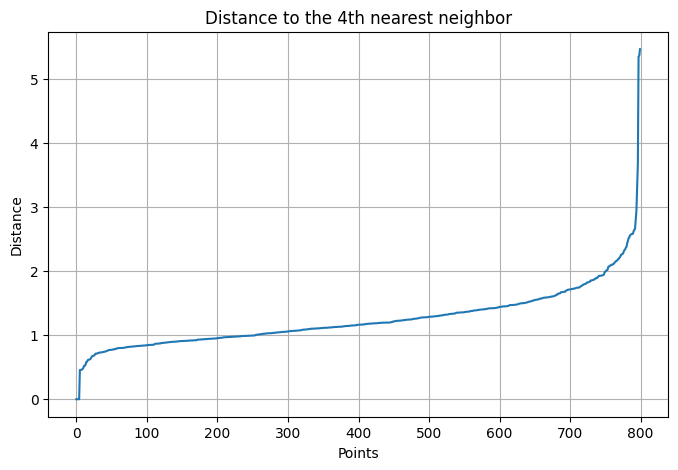

In [15]:
# Distance to the 4th nearest neighbor for each point
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title('Distance to the 4th nearest neighbor')
plt.xlabel('Points')
plt.ylabel('Distance')
plt.grid(True)
plt.show()


What is your chosen eps based on the "elbow"? (2 pts)

In [79]:
# put your answer here
eps = 1.5
print(f"Chosen eps value: {eps}")

Chosen eps value: 1.5


In [80]:
min_samples = k - 1
min_samples_based_features = int(len(df_selected.columns.tolist()) + 1)
print(f'min samples is {min_samples}')
print(f'min samples based on number of features is {min_samples_based_features}')



min samples is 3
min samples based on number of features is 10


One-sentence explanation of your reasoning (2 pts)

# put your answer here

i choosed 1.5 because its the value in the plot where the elbow`s curves beforehand start bending

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [81]:
# put your answer here
dbscan_min_samples = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_based_features = DBSCAN(eps=eps, min_samples=min_samples_based_features)

labels_min_samples = dbscan_min_samples.fit_predict(scaled_data)
labels_based_features = dbscan_based_features.fit_predict(scaled_data)

df_selected_min_sample = df_selected.copy()
df_selected_based_features = df_selected.copy()

df_selected_min_sample['Cluster'] = labels_min_samples
df_selected_based_features['Cluster'] = labels_based_features

In [85]:
print(df_selected_min_sample['Cluster'].value_counts())
df_selected_min_sample.head(15)

Cluster
 0    702
-1     92
 1      3
 2      3
Name: count, dtype: int64


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Cluster
0,1,318,45,49,49,65,65,45,1,0
1,2,405,60,62,63,80,80,60,1,0
2,3,525,80,82,83,100,100,80,1,0
3,3,625,80,100,123,122,120,80,1,-1
4,4,309,39,52,43,60,50,65,1,0
5,5,405,58,64,58,80,65,80,1,0
6,6,534,78,84,78,109,85,100,1,0
7,6,634,78,130,111,130,85,100,1,-1
8,6,634,78,104,78,159,115,100,1,-1
9,7,314,44,48,65,50,64,43,1,0


How many Pokémon were labeled as noise? (4 pts)

In [ ]:
# put your answer here
there are 92 pokemon that were labeled as noise because of the cluster "-1"

Show the unique labels output by DBSCAN (2 pts)

In [83]:
# put your answer here
print(df_selected_min_sample['Cluster'].unique())


[ 0 -1  1  2]


## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [93]:
# put your answer here
df_withclusters = pd.DataFrame()
df_withclusters = df.copy()
df_withclusters['Cluster'] = labels_min_samples
df_withclusters

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,-1
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True,-1
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True,-1
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True,-1
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True,-1


Show the first 10 rows including the cluster label (4 pts)

In [87]:
# put your answer here
df_withclusters.head(10)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Cluster
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,-1
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,0
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False,0
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False,0
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False,-1
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False,-1
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [88]:
# put your answer here
cluster_groups = df_withclusters.groupby('Cluster')['Name'].apply(list)
for cluster, names in cluster_groups.items():
    print(f"Cluster {cluster}: {names}")

Cluster -1: ['VenusaurMega Venusaur', 'CharizardMega Charizard X', 'CharizardMega Charizard Y', 'BlastoiseMega Blastoise', 'BeedrillMega Beedrill', 'Jigglypuff', 'Wigglytuff', 'AlakazamMega Alakazam', 'SlowbroMega Slowbro', 'Cloyster', 'GengarMega Gengar', 'Onix', 'Chansey', 'Mr. Mime', 'PinsirMega Pinsir', 'Magikarp', 'GyaradosMega Gyarados', 'Flareon', 'AerodactylMega Aerodactyl', 'Snorlax', 'Mewtwo', 'MewtwoMega Mewtwo X', 'MewtwoMega Mewtwo Y', 'Igglybuff', 'AmpharosMega Ampharos', 'Wobbuffet', 'Steelix', 'SteelixMega Steelix', 'ScizorMega Scizor', 'Shuckle', 'HeracrossMega Heracross', 'Mantine', 'Blissey', 'TyranitarMega Tyranitar', 'Lugia', 'Ho-oh', 'GardevoirMega Gardevoir', 'Slaking', 'Shedinja', 'Hariyama', 'MawileMega Mawile', 'Aggron', 'AggronMega Aggron', 'Wailmer', 'Wailord', 'CameruptMega Camerupt', 'Kecleon', 'BanetteMega Banette', 'Wynaut', 'Regirock', 'Regice', 'LatiasMega Latias', 'KyogrePrimal Kyogre', 'GroudonPrimal Groudon', 'RayquazaMega Rayquaza', 'DeoxysNormal F

What are the average Attack, Defense, and Speed? (4 pts)



In [89]:
cluster_stats = df_withclusters.groupby('Cluster')[['Attack', 'Defense', 'Speed']].mean()
print("Average Attack, Defense, and Speed for each cluster:")
print(cluster_stats)

Average Attack, Defense, and Speed for each cluster:
             Attack     Defense      Speed
Cluster                                   
-1        99.195652   98.000000  74.597826
 0        76.314815   70.324786  67.529915
 1       106.666667   75.666667  77.666667
 2        60.666667  154.333333  40.000000


Compare the clusters: What differences do you notice? (4 pts)




# put your answer here
Cluster 0 contains most average Pokémon with moderate stats, Cluster 1 has high-Attack fighting types, Cluster 2 includes slow, highly defensive Pokémon, and Cluster -1 consists of legendary or Mega Pokémon with extreme or unique stats.

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [91]:
# put your answer here
outliers = df_withclusters[df_withclusters['Cluster'] == -1]
print(outliers.to_string())


       #                       Name    Type 1    Type 2  Total   HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation  Legendary  Cluster
3      3      VenusaurMega Venusaur     Grass    Poison    625   80     100      123      122      120     80           1      False       -1
7      6  CharizardMega Charizard X      Fire    Dragon    634   78     130      111      130       85    100           1      False       -1
8      6  CharizardMega Charizard Y      Fire    Flying    634   78     104       78      159      115    100           1      False       -1
12     9    BlastoiseMega Blastoise     Water       NaN    630   79     103      120      135      115     78           1      False       -1
19    15      BeedrillMega Beedrill       Bug    Poison    495   65     150       40       15       80    145           1      False       -1
44    39                 Jigglypuff    Normal     Fairy    270  115      45       20       45       25     20           1      False       -1
45    

Are many of them legendary? (3 pts)

In [92]:
# put your answer here
outliers_df = df_withclusters[df_withclusters['Cluster'] == -1]
num_legendary = outliers_df['Legendary'].sum()
total_outliers = len(outliers_df)

print(f'There are {total_outliers} outliers, of which {num_legendary} are Legendary.')



There are 92 outliers, of which 26 are Legendary.


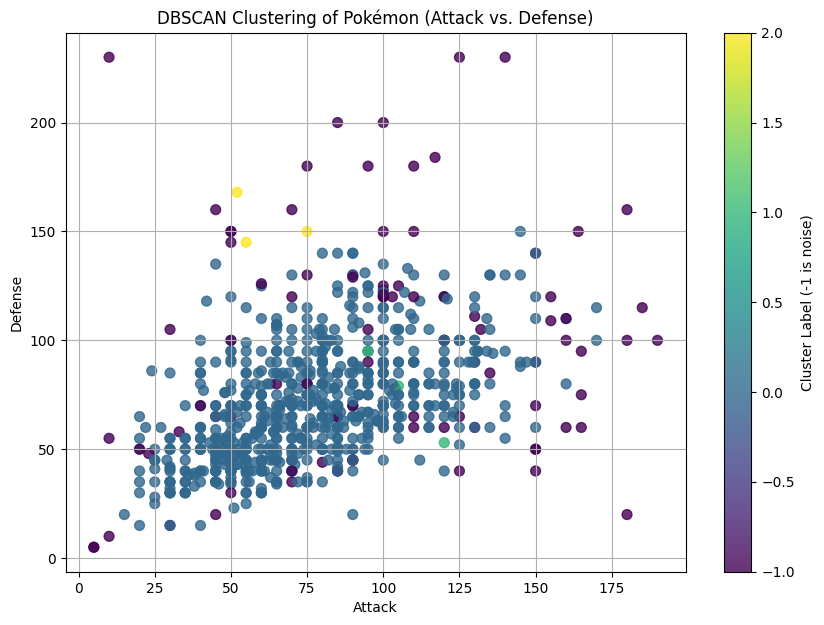

In [94]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_withclusters['Attack'], df_withclusters['Defense'], c=df_withclusters['Cluster'], cmap='viridis', s=50, alpha=0.8)
plt.title('DBSCAN Clustering of Pokémon (Attack vs. Defense)')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.colorbar(scatter, label='Cluster Label (-1 is noise)')
plt.grid(True)
plt.show()

Explain why DBSCAN might classify them as outliers (3 pts)

# put your answer here
DBSCAN might classify these Pokémon as outliers because their stats are extreme or highly unusual compared to the rest of the dataset, making them too far from other points to belong to any dense cluster.

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

# put your answer here
Pokémon of similar primary and secondary types tend to group together; for example, many Fire-types, Water-types, Grass-types, and Psychic-types cluster with others of the same type, often reflecting similar overall stats and roles in battle.

Whether the clusters make intuitive sense (10 pts)

# put your answer here
The clusters make sense numerically, grouping Pokémon with similar base stats, but they don’t always align with types or evolutionary families, and extreme or Legendary Pokémon appear as outliers.


What the noise points reveal about DBSCAN (5 pts)


# put your answer here
The noise points reveal that DBSCAN identifies Pokémon with extreme or unusual stats like Mega Evolutions, Legendary Pokémon, or very weak ones as outliers, showing the algorithm’s ability to detect points that don’t fit well into any dense cluster.strength in detecting anomalies or exceptional cases in a dataset. It shows that the algorithm is not just grouping data but also highlighting points that deviate substantially from common patterns.


What stat patterns you discovered (5 pts)

# put your answer here
The stat patterns show that Pokémon in the same cluster often share similar total stats and distributions across HP, Attack, Defense, Special Attack, Special Defense, and Speed; for example, bulky Pokémon tend to cluster together, fast attackers form another group, and Legendary or Mega Pokémon with unusually high or uneven stats are treated as outliers.Pokémon types, the intuitive sense of the clusters, what noise points reveal about DBSCAN, and any significant statistical patterns discovered.

## Identify and Explain Eps

### Subtask:
Based on the generated elbow plot, identify the optimal 'eps' value by locating the point of maximum curvature where the distance curve sharply changes slope. Then, provide a one-sentence explanation for your choice, justifying why this 'eps' value is suitable for DBSCAN based on the visual interpretation of the plot.


**Reasoning**:
Based on the visual inspection of the elbow plot, I've identified the point where the curve sharply changes slope. I will now input this value and provide a brief explanation for my choice.

